# Python 2DAlphabet ABCDEF Closure Demo

This notebook demonstrates the pure-Python pass/fail fitter in `python/twodalphabet_py.py` using made-up `mtt_vs_mt`-like inputs. The input file is NumPy-only (`outputs/twodalphabet_py_demo/synthetic_mtt_vs_mt_inputs.npz`), and the notebook converts those arrays into `hist.Hist` objects before fitting. The primary `data_fail`/`data_pass` arrays are Asimov counts, so the fitted transfer function should close on the injected truth; Poisson-fluctuated arrays are stored in the same file for later stress tests.

In [26]:
from pathlib import Path
import importlib
import sys

import numpy as np
import hist
import matplotlib.pyplot as plt

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent
sys.path.insert(0, str(repo / "python"))

import twodalphabet_py
twodalphabet_py = importlib.reload(twodalphabet_py)

from twodalphabet_py import (
    Hist2D,
    PassFailModelInput,
    FormulaTransferFunction,
    PassFail2DFitter,
)

input_file = repo / "outputs" / "twodalphabet_py_demo" / "synthetic_mtt_vs_mt_inputs.npz"
data = np.load(input_file)
print(input_file)
print(sorted(data.files))

/run/media/aritra/EXTRA/wsLinux/TTbarHadronicSkimmer/outputs/twodalphabet_py_demo/synthetic_mtt_vs_mt_inputs.npz
['data_fail', 'data_fail_asimov', 'data_fail_poisson', 'data_pass', 'data_pass_asimov', 'data_pass_poisson', 'qcd_fail_truth', 'qcd_pass_truth', 'rpf_truth', 'sig_end', 'sig_start', 'true_params', 'ttbar_fail', 'ttbar_pass', 'x_edges', 'y_edges']


## Build `hist.Hist` Inputs

The fitter accepts `hist.Hist` inputs through `Hist2D.from_hist`. These four templates correspond to observed fail/pass data and fixed simulated non-QCD backgrounds in fail/pass.

In [27]:
def make_hist2d(name, values):
    h = hist.Hist(
        hist.axis.Variable(data["x_edges"], name="jetmass", label="Jet mass [GeV]"),
        hist.axis.Variable(data["y_edges"], name="ttbarmass", label="m_tt [GeV]"),
        storage=hist.storage.Double(),
        name=name,
    )
    h.view(flow=False)[...] = np.asarray(values, dtype=float)
    return h

h_data_fail = make_hist2d("data_fail", data["data_fail"])
h_data_pass = make_hist2d("data_pass", data["data_pass"])
h_ttbar_fail = make_hist2d("ttbar_fail", data["ttbar_fail"])
h_ttbar_pass = make_hist2d("ttbar_pass", data["ttbar_pass"])

inputs = PassFailModelInput(
    data_fail=Hist2D.from_hist(h_data_fail),
    data_pass=Hist2D.from_hist(h_data_pass),
    bkg_fail=Hist2D.from_hist(h_ttbar_fail),
    bkg_pass=Hist2D.from_hist(h_ttbar_pass),
)

print("data fail integral", h_data_fail.sum())
print("data pass integral", h_data_pass.sum())

data fail integral 13000.75056392458
data pass integral 2020.1629741330025


## Fit the ABCDEF 2DAlphabet Core Model

This uses the same core algebra as 2DAlphabet/Combine with the standard blinded ABCDEF layout. The pass signal window `D` is excluded from the likelihood, but the fitted model still predicts it. Coordinates `x` and `y` are bin centers mapped to `[0, 1]`, matching `TwoDAlphabet.alphawrap.ParametricFunction`.

## ABCDEF Region Map

The Python fitter now uses the same six-region sideband idea as the 2DAlphabet setup. The X axis is the top-candidate jet mass (`mt`/`jetmass`); the Y axis is `m_tt`.

```text
                       top-candidate mass axis (mt / jetmass)
                 25-105 GeV       105-210 GeV       210-475 GeV
              +---------------+----------------+----------------+
 FAIL / at    |       A       |       C        |       E        |
              | fail LOW      | fail SIG       | fail HIGH      |
              +---------------+----------------+----------------+
 PASS / 2t    |       B       |       D        |       F        |
              | pass LOW      | pass SIG       | pass HIGH      |
              +---------------+----------------+----------------+

D = blinded pass signal window in the background-only fit.
C remains included: qcd_D is predicted from qcd_C * Rpf(mt, mtt).
B and F constrain the pass/fail transfer function in sidebands.
A, C, and E anchor the free fail-region QCD bin parameters.
```

In code terms:

```text
qcd_fail[x, y] = free positive bin parameter
qcd_pass[x, y] = qcd_fail[x, y] * Rpf(x, y; theta)
fit bins = A + B + C + E + F
blinded prediction = D
```

In [28]:
tf = FormulaTransferFunction(
    "0.1*(@0+@1*x+@2*y)",
    {
        0: {"NOM": 1.0, "MIN": 0.0, "MAX": 5.0, "ERROR": 0.2},
        1: {"NOM": 0.0, "MIN": -5.0, "MAX": 5.0, "ERROR": 0.2},
        2: {"NOM": 0.0, "MIN": -5.0, "MAX": 5.0, "ERROR": 0.2},
    },
)

fitter = PassFail2DFitter.abcdef(
    inputs,
    tf,
    sig_start=float(data["sig_start"]),
    sig_end=float(data["sig_end"]),
    blind_pass_signal=True,
)
fit = fitter.fit(options={"maxiter": 10000, "ftol": 1e-12, "gtol": 1e-8})

print("success:", fit.success)
print("message:", fit.message)
print("nll:", fit.nll)
print("fit params:", fit.params)
print("true params:", data["true_params"])
print("pass bins in fit:", int(np.sum(fit.pass_fit_mask)))
print("pass bins blinded:", int(np.sum(~fit.pass_fit_mask)))

success: True
message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
nll: -60496.70218910514
fit params: {'rpf_par0': 1.3500050199816498, 'rpf_par1': 0.5499838988742539, 'rpf_par2': -0.25000782775392555}
true params: [ 1.35  0.55 -0.25]
pass bins in fit: 40
pass bins blinded: 24


In [29]:
truth = {
    "rpf_par0": data["true_params"][0],
    "rpf_par1": data["true_params"][1],
    "rpf_par2": data["true_params"][2],
}
for name, true_value in truth.items():
    fitted = fit.params[name]
    print(f"{name}: fitted={fitted:.5f}, truth={true_value:.5f}, diff={fitted-true_value:+.5f}")

print("max |fitted rpf - truth rpf|:", np.max(np.abs(fit.rpf - data["rpf_truth"])))
print("qcd_fail truth integral:", data["qcd_fail_truth"].sum())
print("qcd_fail fitted integral:", fit.qcd_fail.sum())
print("qcd_pass truth integral:", data["qcd_pass_truth"].sum())
print("qcd_pass fitted integral:", fit.qcd_pass.sum())
print()
print("ABCDEF yields:")
for source, yields in fit.abcdef_yields.items():
    formatted = ", ".join(f"{region}={value:.2f}" for region, value in yields.items())
    print(f"  {source}: {formatted}")

rpf_par0: fitted=1.35001, truth=1.35000, diff=+0.00001
rpf_par1: fitted=0.54998, truth=0.55000, diff=-0.00002
rpf_par2: fitted=-0.25001, truth=-0.25000, diff=-0.00001
max |fitted rpf - truth rpf|: 1.6091084188152305e-06
qcd_fail truth integral: 12492.621459667847
qcd_fail fitted integral: 12492.622846330725
qcd_pass truth integral: 1829.7086385284535
qcd_pass fitted integral: 1829.706410063239

ABCDEF yields:
  data: A=4379.47, B=605.44, C=5330.19, D=836.21, E=3291.09, F=578.52
  qcd: A=4245.95, B=567.97, C=5046.35, D=730.40, E=3200.32, F=531.34
  expected: A=4379.47, B=605.44, C=5330.19, D=836.20, E=3291.09, F=578.51


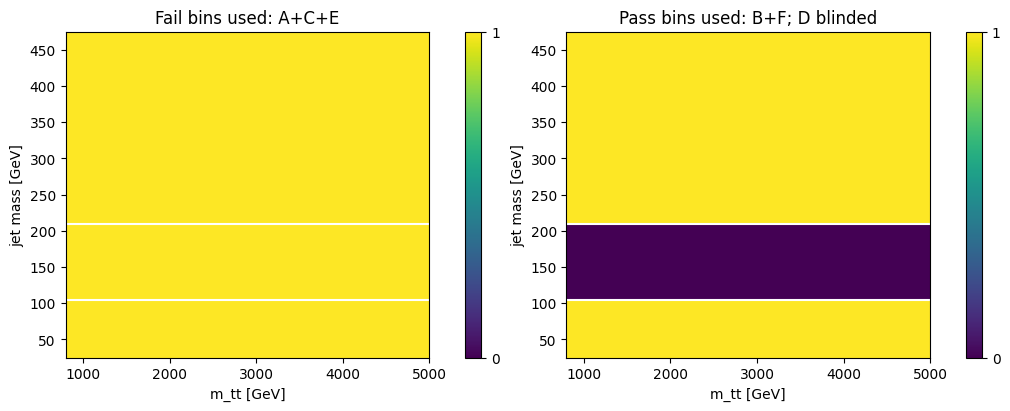

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, mask, title in [
    (axes[0], fit.fail_fit_mask, "Fail bins used: A+C+E"),
    (axes[1], fit.pass_fit_mask, "Pass bins used: B+F; D blinded"),
]:
    mesh = ax.pcolormesh(data["y_edges"], data["x_edges"], mask.astype(int), shading="auto", vmin=0, vmax=1)
    ax.axhline(float(data["sig_start"]), color="white", linewidth=1.5)
    ax.axhline(float(data["sig_end"]), color="white", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("m_tt [GeV]")
    ax.set_ylabel("jet mass [GeV]")
    fig.colorbar(mesh, ax=ax, ticks=[0, 1])
plt.show()

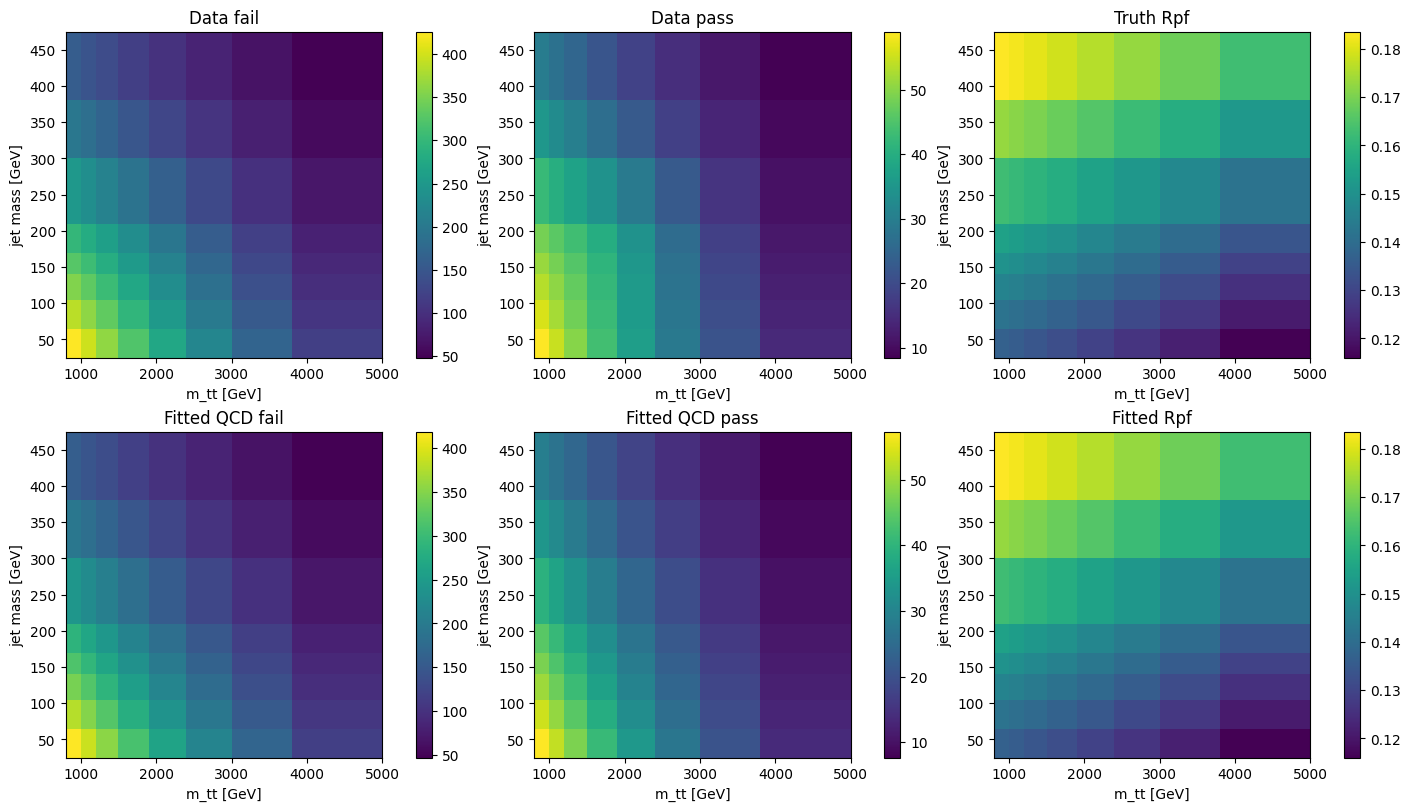

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
plots = [
    (data["data_fail"], "Data fail"),
    (data["data_pass"], "Data pass"),
    (data["rpf_truth"], "Truth Rpf"),
    (fit.qcd_fail, "Fitted QCD fail"),
    (fit.qcd_pass, "Fitted QCD pass"),
    (fit.rpf, "Fitted Rpf"),
]
for ax, (values, title) in zip(axes.ravel(), plots):
    mesh = ax.pcolormesh(data["y_edges"], data["x_edges"], values, shading="auto")
    ax.set_title(title)
    ax.set_xlabel("m_tt [GeV]")
    ax.set_ylabel("jet mass [GeV]")
    fig.colorbar(mesh, ax=ax)
plt.show()

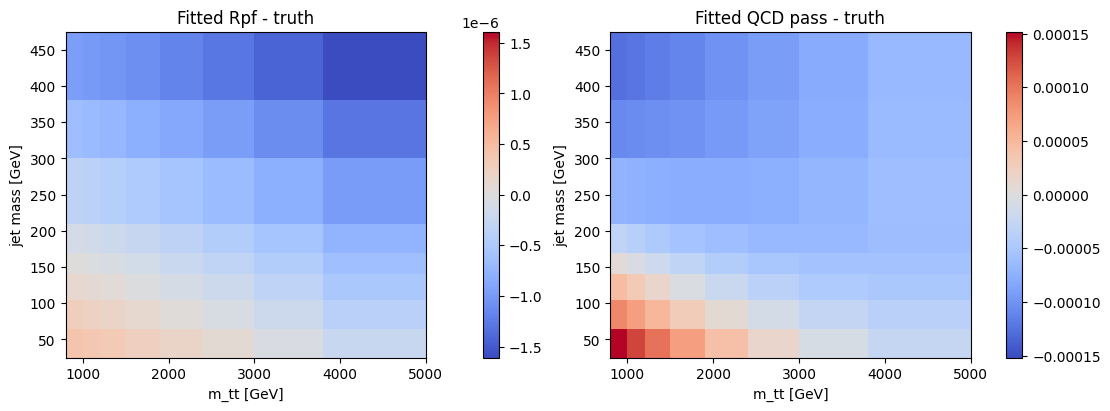

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, values, title in [
    (axes[0], fit.rpf - data["rpf_truth"], "Fitted Rpf - truth"),
    (axes[1], fit.qcd_pass - data["qcd_pass_truth"], "Fitted QCD pass - truth"),
]:
    vmax = np.max(np.abs(values))
    mesh = ax.pcolormesh(
        data["y_edges"],
        data["x_edges"],
        values,
        shading="auto",
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("m_tt [GeV]")
    ax.set_ylabel("jet mass [GeV]")
    fig.colorbar(mesh, ax=ax)
plt.show()